# HQNN-Parallel with a **ViT** classical backbone — Google Colab (hybrid GPU/CPU)

This is the first model from Senokosov et al. 2024 (*"Quantum machine learning
for image classification"*, Mach. Learn.: Sci. Technol. **5** 015040,
**section 2.2**, HQNN-Parallel), but with the classical **CNN feature extractor
replaced by a simple Vision Transformer (ViT)**. The quantum part — a set of
**parallel parameterised quantum circuits (PQCs)** — is unchanged from the paper.

### Architecture
- **Classical backbone = simple ViT only** (no convolutions):
  patchify 28×28 → 7×7 patches (49 patches, patch_size 4) → linear patch embedding (dim 128)
  → CLS token + positional embeddings → 4 Transformer encoder layers (8 heads)
  → CLS representation (128-dim).
- **Hybrid dense head (widened):** Linear(128 → 64) → GELU → Linear(64 → 20) → BatchNorm → ReLU
  → **parallel quantum layer** (4 circuits × 5 qubits) → Linear(20 → 10) → BatchNorm.

### Quantum layer (unchanged from the paper)
4 parallel PQCs, each on 5 qubits: RX angle embedding → 4 strongly-entangling
layers (trainable rotations + CNOT ring) → Pauli-Y measurement. The 20-dim
bottleneck is split into 4 chunks of 5, one per circuit, then concatenated back.

### Hybrid GPU/CPU split
- **Quantum circuits run on CPU** (PennyLane `default.qubit`), pinned so
  `model.to('cuda')` never moves them to the GPU.
- **ViT + linear layers run on the GPU** when a GPU runtime is selected; the
  small 20-dim bottleneck is moved to CPU for the circuits and back each step
  (autograd handles the transfer).

To use a GPU: **Runtime → Change runtime type → Hardware accelerator → GPU**.

In [ ]:
# 1. Install quantum ML dependencies (torch/torchvision ship with Colab).
!pip install -q pennylane pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.6 MB/s eta 0:00:00


In [ ]:
# 2. Imports, seed, device. ViT + linear layers use the GPU if available;
#    the quantum circuits always run on CPU (see the model below).
import time
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PennyLane", qml.__version__, "| Torch", torch.__version__)
print("Classical device:", device, "| Quantum device: cpu (default.qubit)")

PennyLane 0.45.1 | Torch 2.11.0+cu128
Classical device: cuda | Quantum device: cpu (default.qubit)


## Quantum layer (parallel PQCs) — unchanged from the paper

In [ ]:
# 3. Parallel quantum layer.
def _make_qnode(n_qubits, device_name="default.qubit", diff_method="backprop"):
    """PQC: RX angle embedding -> strongly entangling layers -> Pauli-Y expvals."""
    dev = qml.device(device_name, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method=diff_method)
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="X")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliY(i)) for i in range(n_qubits)]

    return circuit


class ParallelQuantumLayer(nn.Module):
    """n_circuits PQCs in parallel: (B, c*q) -> split into c chunks of q -> (B, c*q)."""
    def __init__(self, n_qubits=5, n_layers=3, n_circuits=4):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_circuits = n_circuits
        self.n_features = n_qubits * n_circuits
        qnode = _make_qnode(n_qubits)
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}  # StronglyEntanglingLayers
        self.circuits = nn.ModuleList(
            [qml.qnn.TorchLayer(qnode, weight_shapes) for _ in range(n_circuits)]
        )

    def forward(self, x):
        chunks = torch.split(x, self.n_qubits, dim=1)
        outs = [c(chunk) for c, chunk in zip(self.circuits, chunks)]
        return torch.cat(outs, dim=1)

    def _apply(self, fn, *args, **kwargs):
        # Pin circuit weights to CPU: ignore device-moving .to('cuda')/.cuda()
        # calls (default.qubit simulates on CPU) but honour dtype changes.
        try:
            if fn(torch.zeros(1)).device.type != "cpu":
                return self
        except Exception:
            pass
        return super()._apply(fn, *args, **kwargs)

## Classical backbone — simple ViT

In [ ]:
# 4. A minimal Vision Transformer (the only classical feature extractor).
class SimpleViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, in_channels=1,
                 dim=128, depth=4, heads=8, mlp_dim=256, dropout=0.05):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        num_patches = (image_size // patch_size) ** 2       # 49 with patch_size=4
        patch_dim = in_channels * patch_size * patch_size   # 16 with patch_size=4

        self.patch_size = patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.patch_embed = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.dim = dim

    def forward(self, x):
        B = x.shape[0]
        patches = self.unfold(x).transpose(1, 2)      # (B, num_patches, patch_dim)
        x = self.patch_embed(patches)                 # (B, num_patches, dim)
        cls = self.cls_token.expand(B, -1, -1)        # (B, 1, dim)
        x = torch.cat([cls, x], dim=1)                # (B, num_patches+1, dim)
        x = self.dropout(x + self.pos_embed)
        x = self.transformer(x)                       # (B, num_patches+1, dim)
        return self.norm(x[:, 0])                     # CLS token -> (B, dim)


## Full model — ViT backbone + parallel quantum dense head

In [ ]:
# 5. HQNN-Parallel with a ViT backbone.
class HQNNParallelViT(nn.Module):
    def __init__(self, image_size=28, in_channels=1, num_classes=10,
                 vit_dim=128, vit_depth=4, vit_heads=8, vit_mlp_dim=256, patch_size=4,
                 n_qubits=5, n_layers=4, n_circuits=4):
        super().__init__()
        self.vit = SimpleViT(image_size=image_size, patch_size=patch_size,
                             in_channels=in_channels, dim=vit_dim, depth=vit_depth,
                             heads=vit_heads, mlp_dim=vit_mlp_dim)
        self.n_features = n_qubits * n_circuits       # 20 (paper's "n")

        # Widen before the quantum bottleneck instead of squeezing vit_dim -> 20 directly.
        self.pre = nn.Sequential(
            nn.Linear(vit_dim, 64), nn.GELU(),
            nn.Linear(64, self.n_features),
        )
        self.bn1 = nn.BatchNorm1d(self.n_features)
        self.quantum = ParallelQuantumLayer(n_qubits, n_layers, n_circuits)
        self.fc2 = nn.Linear(self.n_features, num_classes)
        self.bn2 = nn.BatchNorm1d(num_classes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.vit(x)                               # ViT backbone (GPU)
        x = self.relu(self.bn1(self.pre(x)))
        # Quantum circuits run on CPU: move the small bottleneck to CPU and back.
        classical_device = x.device
        x = self.quantum(x.to("cpu")).to(classical_device)
        x = self.bn2(self.fc2(x))
        return x  # logits


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


## Configuration

In [ ]:
# 6. Config. QUICK=True -> fast smoke test; QUICK=False -> full MNIST.
QUICK = False

if QUICK:
    EPOCHS, BATCH_SIZE = 3, 128
    TRAIN_SUBSET, TEST_SUBSET = 3000, 1000
else:
    EPOCHS, BATCH_SIZE = 35, 256
    TRAIN_SUBSET, TEST_SUBSET = None, None  # full 60k / 10k

LR = 5e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 3
USE_COSINE = True

# Light data augmentation. The bigger ViT should now fit the training set well;
# if train accuracy stalls below ~98%, set AUGMENT=False (augmenting while the
# model is still underfitting makes fitting harder, not easier).
AUGMENT = True

print(f"QUICK={QUICK} | epochs={EPOCHS} batch={BATCH_SIZE} lr={LR} wd={WEIGHT_DECAY} "
      f"warmup={WARMUP_EPOCHS} augment={AUGMENT} "
      f"train_subset={TRAIN_SUBSET} test_subset={TEST_SUBSET}")


QUICK=False | epochs=35 batch=256 lr=0.0005 wd=0.0001 warmup=3 augment=True train_subset=None test_subset=None


## Data — MNIST

In [ ]:
# 7. MNIST loaders.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
if AUGMENT:
    train_transform = transforms.Compose([
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
else:
    train_transform = test_transform

train_set = datasets.MNIST("./data", train=True,  download=True, transform=train_transform)
test_set  = datasets.MNIST("./data", train=False, download=True, transform=test_transform)
if TRAIN_SUBSET:
    train_set = Subset(train_set, range(TRAIN_SUBSET))
if TEST_SUBSET:
    test_set = Subset(test_set, range(TEST_SUBSET))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)
print(f"train={len(train_set)}  test={len(test_set)}  augment={AUGMENT}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]

train=60000  test=10000  augment=True


## Training

In [ ]:
# 8. Train / eval loops.
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
# 9. Build the model and train.
model = HQNNParallelViT().to(device)
print("Trainable parameters:", count_parameters(model))
print("Quantum bottleneck n =", model.n_features, "(4 circuits x 5 qubits)")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

if USE_COSINE:
    # Short linear warmup (ViTs are sensitive to it) then cosine decay.
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS))
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])
else:
    scheduler = None

history = {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}
best_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    if scheduler:
        scheduler.step()
    history["train_acc"].append(tr_acc); history["test_acc"].append(te_acc)
    history["train_loss"].append(tr_loss); history["test_loss"].append(te_loss)
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "hqnn_parallel_vit_mnist.pt")
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% | "
          f"test loss {te_loss:.4f} acc {te_acc*100:5.2f}% | {time.time()-t0:.1f}s")

print(f"\nBest test accuracy: {best_acc*100:.2f}%")


Trainable parameters: 548946
Quantum bottleneck n = 20 (4 circuits x 5 qubits)
Epoch   1/35 | train loss 2.1738 acc 22.75% | test loss 1.8734 acc 31.40% | 112.4s
Epoch   2/35 | train loss 1.5850 acc 42.95% | test loss 1.3445 acc 52.78% | 102.9s
Epoch   3/35 | train loss 1.1658 acc 62.30% | test loss 0.7227 acc 79.66% | 105.1s
Epoch   4/35 | train loss 0.7679 acc 78.73% | test loss 0.4640 acc 88.26% | 100.1s
Epoch   5/35 | train loss 0.5363 acc 86.05% | test loss 0.2898 acc 93.94% | 104.0s
Epoch   6/35 | train loss 0.4086 acc 89.63% | test loss 0.2135 acc 95.27% | 102.1s
Epoch   7/35 | train loss 0.3304 acc 91.90% | test loss 0.1764 acc 96.47% | 102.8s
Epoch   8/35 | train loss 0.2781 acc 93.24% | test loss 0.1298 acc 97.58% | 104.1s
Epoch   9/35 | train loss 0.2398 acc 94.14% | test loss 0.1307 acc 97.34% | 107.4s
Epoch  10/35 | train loss 0.2081 acc 94.84% | test loss 0.1000 acc 97.93% | 104.8s
Epoch  11/35 | train loss 0.1804 acc 95.61% | test loss 0.1190 acc 97.28% | 108.9s
Epoch  1

## Results

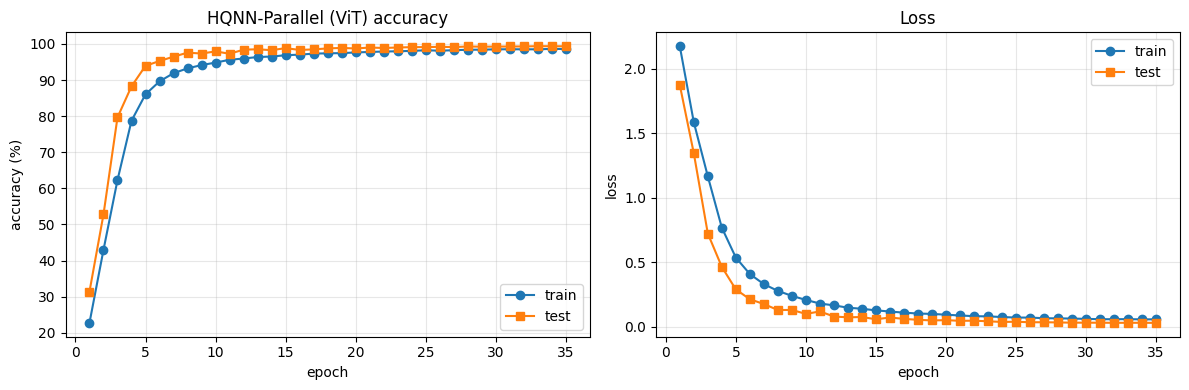

In [ ]:
# 10. Learning curves.
epochs = range(1, len(history["train_acc"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [a*100 for a in history["train_acc"]], "o-", label="train")
ax1.plot(epochs, [a*100 for a in history["test_acc"]],  "s-", label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("accuracy (%)")
ax1.set_title("HQNN-Parallel (ViT) accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, history["train_loss"], "o-", label="train")
ax2.plot(epochs, history["test_loss"],  "s-", label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# 11. Download the trained weights.
from google.colab import files
files.download("hqnn_parallel_vit_mnist.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>